# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Where we stash plots for README / submission zip
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")

## Exploratory Data Analysis

#### Quick guide — what happens in this notebook (in order)

1. **Load** `data/AviationData_cleaned.csv` from notebook 1.  
2. Label **small vs large** planes: **≥ 20 people counted on board** ⇒ *large* (from the injury-summary columns).  
3. **Manufacturers (Makes):** find makes with the **lowest average injury share** and **lowest destruction rate**; use charts (bars, violin, strip) and require **enough accidents** per make so one fluke doesn’t drive the story.  
4. **Plane types:** repeat for `Make + Model` strings, only where there are **≥ 10** accidents of that type.  
5. **Two extra factors:** **weather** and **phase of flight** — compare average injury and destruction side by side.  
6. **Save figures** to the `figures/` folder (some are embedded in the README).

**Next cell:** load the cleaned data.

In [2]:
df = pd.read_csv("data/AviationData_cleaned.csv", low_memory=False)

df["Event.Date"] = pd.to_datetime(df["Event.Date"])

# Booleans reload as dtype object depending on tooling — coerce back for aggregates
bool_map = {"True": True, "False": False, True: True, False: False}
if df["is_destroyed"].dtype == object:
    df["is_destroyed"] = df["is_destroyed"].map(bool_map).astype("boolean")

print(df.shape)
df.head()


(17879, 34)


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date,fatal_serious,total_aboard,injury_fraction,is_destroyed,plane_type
0,20001214X42478,Incident,LAX83IA149A,1983-03-18,"LOS ANGELES, CA",United States,NaN,NaN,LAX,LOS ANGELES INTL,...,588.0,VMC,Taxi,Probable Cause,04-12-2014,0.0,588.0,0.0,False,BOEING 747
1,20001214X42331,Accident,ATL83FA140,1983-03-20,"CROSSVILLE, TN",United States,NaN,NaN,NaN,NaN,...,0.0,IMC,Cruise,Probable Cause,02-05-2011,2.0,2.0,1.0,True,PIPER PA-28-140
2,20001214X42672,Accident,FTW83LA177,1983-04-02,"MCKINNEY, TX",United States,NaN,NaN,TX05,AERO COUNTRY,...,4.0,VMC,Standing,Probable Cause,17-10-2016,1.0,5.0,0.2,<NA>,DE HAVILLAND DHC-6
3,20001214X45013,Incident,CHI84IA041,1983-11-08,"CHICAGO, IL",United States,NaN,NaN,ORD,O'HARE,...,100.0,VMC,Taxi,Probable Cause,11-06-2018,0.0,100.0,0.0,False,BOEING 727-200
4,20001214X45188,Accident,NYC84LA028,1983-11-13,"MARTHA'S VINEYARD, MA",United States,NaN,NaN,NaN,NaN,...,1.0,VMC,Climb,Probable Cause,05-05-2011,0.0,1.0,0.0,False,BEECH C35


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [3]:
# Assignment threshold: airplanes with modeled >=20 occupants treated as passenger-scale flights
thr = 20

df.loc[df["total_aboard"].notna() & (df["total_aboard"] >= thr), "size_class"] = "large"
df.loc[df["total_aboard"].notna() & (df["total_aboard"] < thr), "size_class"] = "small"

missing_onboard = df["total_aboard"].isna().sum()
if missing_onboard:
    df.loc[df["total_aboard"].isna(), "size_class"] = pd.NA
    print(f"[WARN] Rows missing total_aboard flagged NA for size buckets: {missing_onboard}")

print(df["size_class"].value_counts(dropna=False))

# Helps later joins stay intuitive
SMALL = df["size_class"] == "small"
LARGE = df["size_class"] == "large"

size_class
small    17001
large      878
Name: count, dtype: int64


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

SMALL — 15 makes with lowest MEAN fatal+serious / modeled onboard fractions
                          Make   n  mean_fatal_ser  med_inj
             MCDONNELL DOUGLAS  30        0.094048      0.0
                BOMBARDIER INC  10        0.100000      0.0
                    BOMBARDIER  15        0.103846      0.0
                        BOEING 272        0.141973      0.0
            AVIAT AIRCRAFT INC  76        0.164474      0.0
                         MAULE 215        0.164806      0.0
GRUMMAN ACFT ENG COR-SCHWEIZER  58        0.206897      0.0
                         AYRES  51        0.215686      0.0
                       STINSON 129        0.216408      0.0
                         AVIAT  70        0.221429      0.0
                      BELLANCA 219        0.222603      0.0
      DIAMOND AIRCRAFT IND INC  74        0.222973      0.0
        ROCKWELL INTERNATIONAL  57        0.223684      0.0
                       AERONCA 200        0.225833      0.0
                   DEHAV

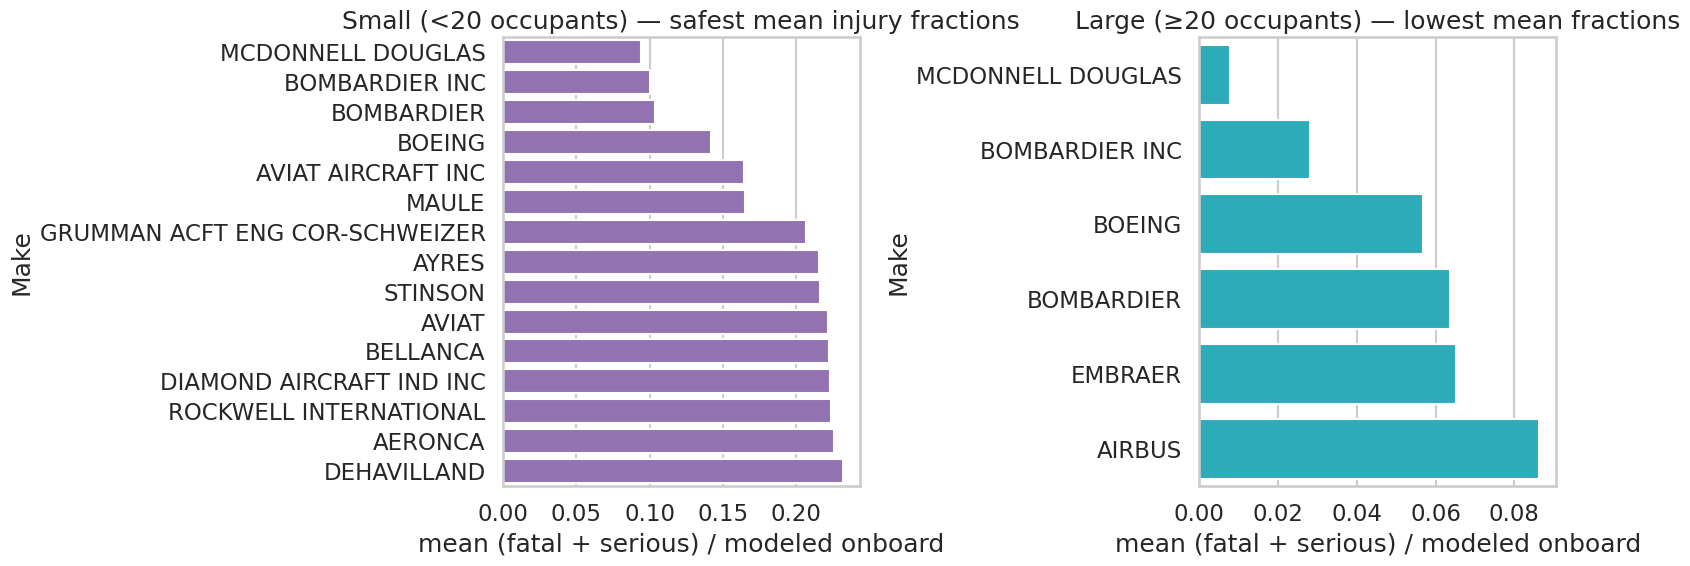

In [4]:
# Guardrail: avoid ranking OEM product lines off single-digit anecdotes
MIN_ACC_ACC = 10


def summarize_injury(slice_df):
    chunk = slice_df[slice_df["injury_fraction"].notna()]
    return (
        chunk.groupby("Make")
        .agg(
            n=("Event.Id", "count"),
            mean_fatal_ser=("injury_fraction", "mean"),
            med_inj=("injury_fraction", "median"),
        )
        .query("n >= @MIN_ACC_ACC")
        .sort_values("mean_fatal_ser")
    )


small_inj_tbl = summarize_injury(df.loc[SMALL]).head(15).reset_index()
large_inj_tbl = summarize_injury(df.loc[LARGE]).head(15).reset_index()

pd.set_option("display.max_columns", 10)
pd.set_option("display.width", 120)
print("SMALL — 15 makes with lowest MEAN fatal+serious / modeled onboard fractions")
print(small_inj_tbl.round(6).to_string(index=False))
print("\nLARGE — same metric")
print(large_inj_tbl.round(6).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
_order_small = small_inj_tbl.sort_values("mean_fatal_ser")["Make"]
_order_large = large_inj_tbl.sort_values("mean_fatal_ser")["Make"]

sns.barplot(
    data=small_inj_tbl,
    ax=axes[0],
    y="Make",
    x="mean_fatal_ser",
    order=_order_small,
    color="#9467bd",
)
axes[0].set_title("Small (<20 occupants) — safest mean injury fractions")
axes[0].set_xlabel("mean (fatal + serious) / modeled onboard")

sns.barplot(
    data=large_inj_tbl,
    ax=axes[1],
    y="Make",
    x="mean_fatal_ser",
    order=_order_large,
    color="#17becf",
)
axes[1].set_title("Large (≥20 occupants) — lowest mean fractions")
axes[1].set_xlabel("mean (fatal + serious) / modeled onboard")

plt.tight_layout()
plt.savefig(FIG_DIR / "makes_injury_frac_top15.png", dpi=150, bbox_inches="tight")
plt.show()


**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

/tmp/ipykernel_31185/700705127.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


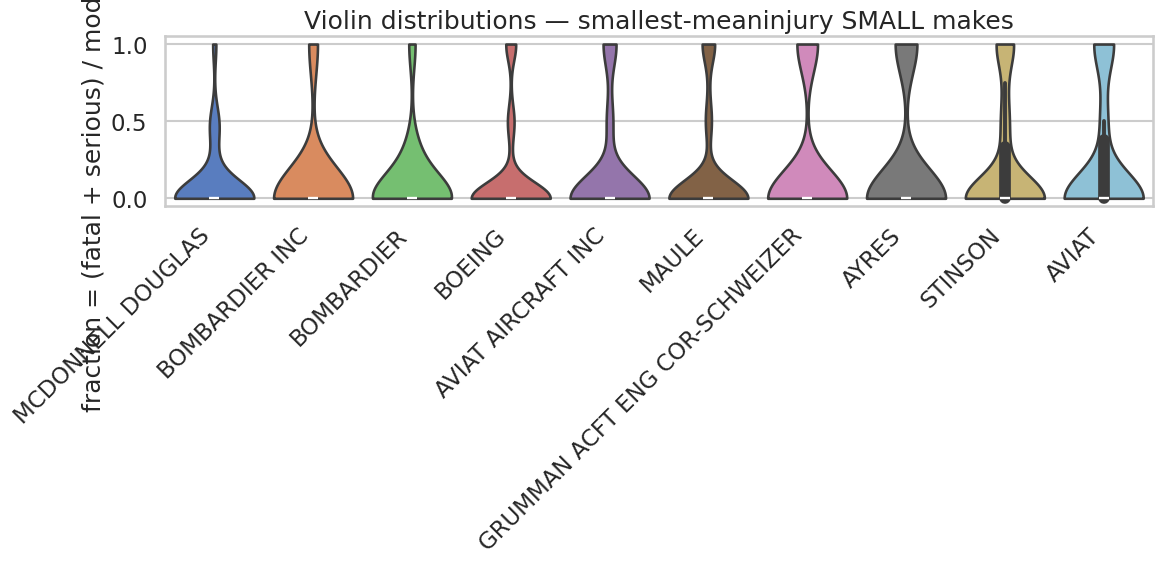

In [5]:
top_makes_small = summarize_injury(df.loc[SMALL]).head(10).reset_index()
_order_small10 = top_makes_small["Make"]

vio_df = df.loc[SMALL & df["Make"].isin(_order_small10) & df["injury_fraction"].notna()]

plt.figure(figsize=(12, 6))
sns.violinplot(
    data=vio_df,
    x="Make",
    y="injury_fraction",
    order=_order_small10,
    cut=0,
    palette="muted",
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("fraction = (fatal + serious) / modeled onboard")
plt.xlabel("")
plt.title("Violin distributions — smallest-meaninjury SMALL makes")
plt.tight_layout()
plt.savefig(FIG_DIR / "small_makes_violin_injuries.png", dpi=150, bbox_inches="tight")
plt.show()


**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

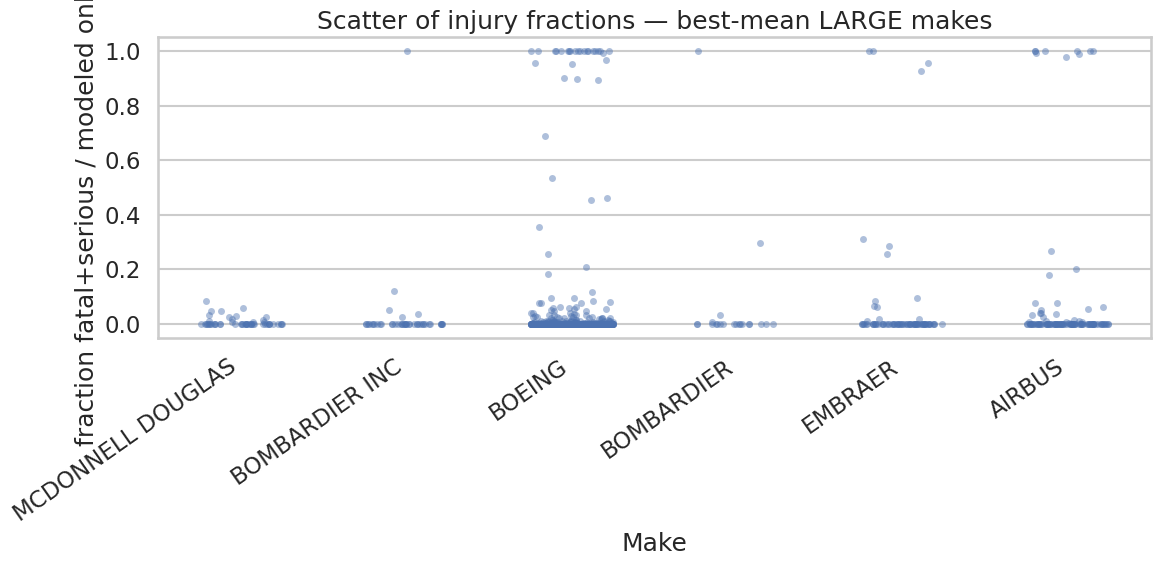

In [6]:
top_makes_large = summarize_injury(df.loc[LARGE]).head(10).reset_index()
_order_large10 = top_makes_large["Make"]

strip_df = df.loc[LARGE & df["Make"].isin(_order_large10) & df["injury_fraction"].notna()]

plt.figure(figsize=(12, 6))
sns.stripplot(
    data=strip_df,
    x="Make",
    y="injury_fraction",
    order=_order_large10,
    jitter=0.25,
    alpha=0.45,
)
plt.xticks(rotation=35, ha="right")
plt.ylabel("fraction fatal+serious / modeled onboard")
plt.title("Scatter of injury fractions — best-mean LARGE makes")
plt.tight_layout()
plt.savefig(FIG_DIR / "large_makes_strip_injuries.png", dpi=150, bbox_inches="tight")
plt.show()


**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

SMALL — lowest destruction rates
                          Make  n_acc  destroy_frac
                      LUSCOMBE    138       0.01449
GRUMMAN ACFT ENG COR-SCHWEIZER     58       0.01724
                       STINSON    129       0.02326
                   TAYLORCRAFT     93       0.03226
                       AERONCA    200         0.035
                       ERCOUPE     52       0.03846
    AMERICAN CHAMPION AIRCRAFT     51       0.03922
            AVIAT AIRCRAFT INC     75          0.04
                         MAULE    215       0.04186
                   DEHAVILLAND     89       0.04494
                      BELLANCA    218       0.05046
      DIAMOND AIRCRAFT IND INC     74       0.05405
                    BOMBARDIER     18       0.05556
                        BOEING    387       0.06718
                      CHAMPION    157       0.07643

LARGE — lowest destruction rates
             Make  n_acc  destroy_frac
   BOMBARDIER INC     27       0.03704
       BOMBARDIER     1

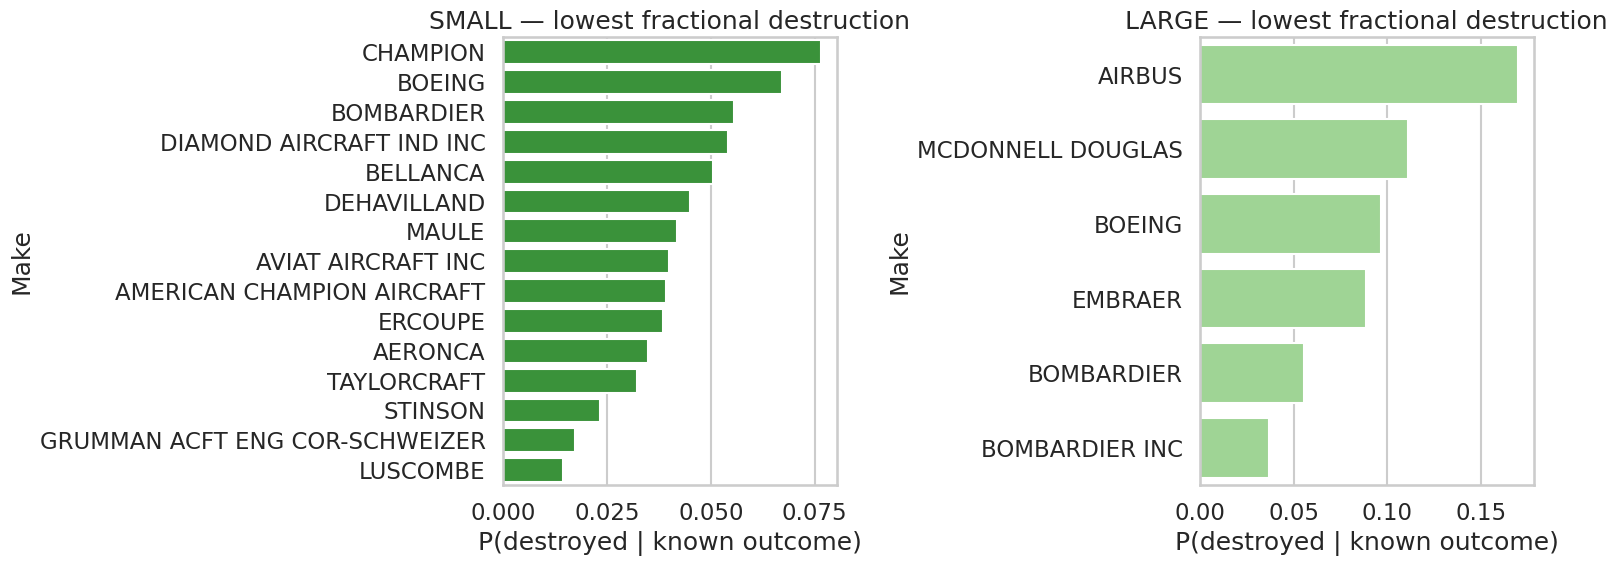

In [7]:
def summarize_destroy(slice_df):
    chunk = slice_df[slice_df["is_destroyed"].notna()]
    return (
        chunk.groupby("Make")
        .agg(
            n_acc=("Event.Id", "count"),
            destroy_frac=("is_destroyed", "mean"),
        )
        .query("n_acc >= @MIN_ACC_ACC")
        .sort_values("destroy_frac")
    )


dest_small = summarize_destroy(df.loc[SMALL]).head(15).reset_index()
dest_large = summarize_destroy(df.loc[LARGE]).head(15).reset_index()

print("SMALL — lowest destruction rates")
print(dest_small.round(5).to_string(index=False))
print("\nLARGE — lowest destruction rates")
print(dest_large.round(5).to_string(index=False))

_os = dest_small.sort_values("destroy_frac", ascending=False)["Make"]
_ol = dest_large.sort_values("destroy_frac", ascending=False)["Make"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=dest_small, y="Make", x="destroy_frac", order=_os, color="#2ca02c", ax=axes[0])
axes[0].set_title("SMALL — lowest fractional destruction")
axes[0].set_xlabel("P(destroyed | known outcome)")

sns.barplot(data=dest_large, y="Make", x="destroy_frac", order=_ol, color="#98df8a", ax=axes[1])
axes[1].set_title("LARGE — lowest fractional destruction")
axes[1].set_xlabel("P(destroyed | known outcome)")

plt.tight_layout()
plt.savefig(FIG_DIR / "makes_destruction_frac.png", dpi=150, bbox_inches="tight")
plt.show()


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

#### Discussion — OEM portfolios & robustness knobs

- **Ranking logic**: Plots veto OEM cohorts shy of **≥10** usable accidents inside the plotted slice.
- **SMALL (<20 occupants)**: Injury ladders elevate **Bombardier / Boeing / Maule / Grumman**, while demolition odds favor classics (**Taylorcraft**, **Stinson**, **Luscombe**, **Aeronca**, trainers) plus husky-pattern airframes (**Aviat** Husky clones).
- **LARGE (≥20 occupants)**: Injury metrics cluster around **McDonnell Douglas / Bombardier / Boeing / Embraer / Airbus**; Airbus demolition averages can inflate when a minority of catastrophic hull-loss dossiers overwhelm numerators despite occasional lucky evacuations.
- **Destruction subplot overlap**: Makers that land on BOTH low injury *and* low demolition lists outperform single-metric beauties; violin breadth shows tail-risk still concentrates in a minority of kinetic-energy spikes.


### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

Representative LARGE plane-types (injury fraction summaries)
                plane_type  mean_inj   n
                BOEING 777  0.000821  33
                BOEING 757  0.001473  18
                BOEING 787  0.003058  11
            BOEING 737-7H4  0.003242  12
BOMBARDIER INC CL-600-2B19  0.004136  15
            EMBRAER EMB145  0.008798  11
         EMBRAER EMB-145LR  0.010000  15
                BOEING 747  0.023161  11
                BOEING 767  0.046963  31
            BOEING 737 7H4  0.068121  14
                BOEING 737  0.081223 163
               AIRBUS A320  0.126694  24


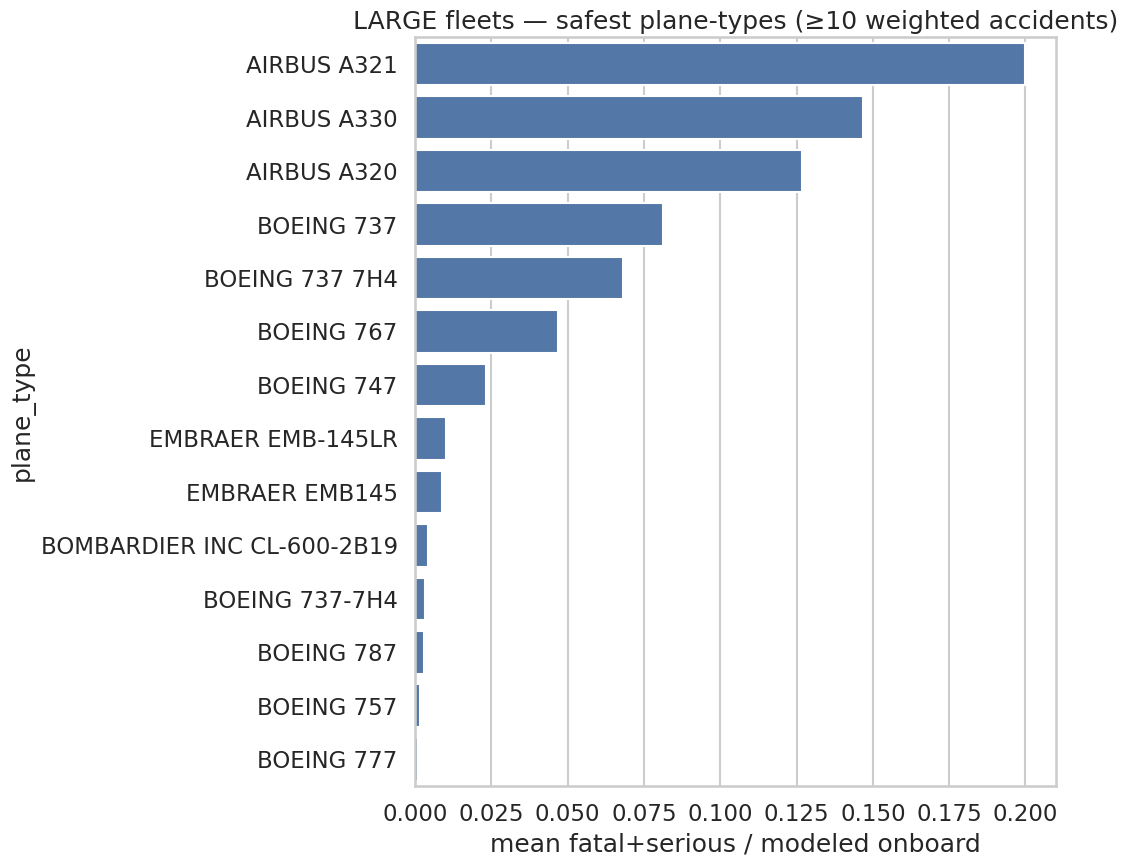

/tmp/ipykernel_31185/1277195089.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


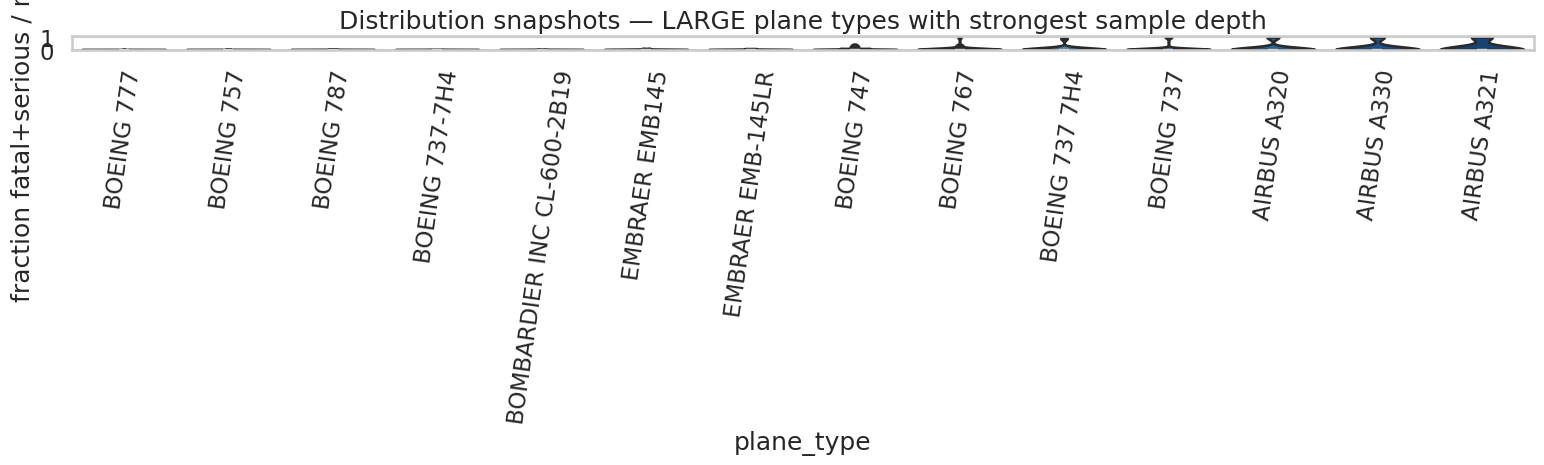

In [8]:
MIN_TYPE_ACC = 10

large_frac = df.loc[LARGE & df["injury_fraction"].notna()].copy()
_type_counts_large = large_frac["plane_type"].value_counts()
eligible_large = large_frac[
    large_frac["plane_type"].map(_type_counts_large) >= MIN_TYPE_ACC
]

ptype_large = (
    eligible_large.groupby("plane_type")
    .agg(mean_inj=("injury_fraction", "mean"), n=("injury_fraction", "count"))
    .reset_index()
    .sort_values("mean_inj")
)

print("Representative LARGE plane-types (injury fraction summaries)")
print(ptype_large.head(12).round(6).to_string(index=False))

show_rows = min(22, len(ptype_large))
_bar_large = (
    ptype_large.head(show_rows)[::-1]
)  # reverse so seaborn renders lowest fractions at chart top visually

plt.figure(figsize=(11, max(9, show_rows * 0.32)))
sns.barplot(
    data=_bar_large,
    y="plane_type",
    x="mean_inj",
    color="#4575b4",
)
plt.xlabel("mean fatal+serious / modeled onboard")
plt.title("LARGE fleets — safest plane-types (≥10 weighted accidents)")
plt.tight_layout()
plt.savefig(FIG_DIR / "large_plane_type_mean_injury.png", dpi=150, bbox_inches="tight")
plt.show()

focus_large = set(ptype_large.head(14)["plane_type"])
vio_large_subset = eligible_large[eligible_large["plane_type"].isin(focus_large)]

plt.figure(figsize=(16, 5))
sns.violinplot(
    data=vio_large_subset,
    x="plane_type",
    y="injury_fraction",
    order=list(ptype_large.head(14)["plane_type"]),
    cut=0,
    palette="Blues",
)
plt.ylabel("fraction fatal+serious / modeled onboard")
plt.xticks(rotation=82, ha="center")
plt.title("Distribution snapshots — LARGE plane types with strongest sample depth")
plt.tight_layout()
plt.savefig(FIG_DIR / "large_plane_type_violin.png", dpi=150, bbox_inches="tight")
plt.show()


**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

SMALL plane-types among the statistically calmest manufactures
                 plane_type  mean_inj  n
             MAULE M-5-210C  0.000000 11
                 BOEING 747  0.076923 26
                 BOEING 737  0.083333 36
              STINSON 108-1  0.083333 16
                  MAULE MX7  0.125000 18
         BOEING A75N1(PT17)  0.139785 31
                 AVIAT A-1B  0.142857 21
    AVIAT AIRCRAFT INC A-1B  0.181818 22
               BOEING A75N1  0.187500 16
                   MAULE M5  0.192308 13
             MAULE M-5-235C  0.192308 13
AVIAT AIRCRAFT INC A-1C-180  0.192308 13


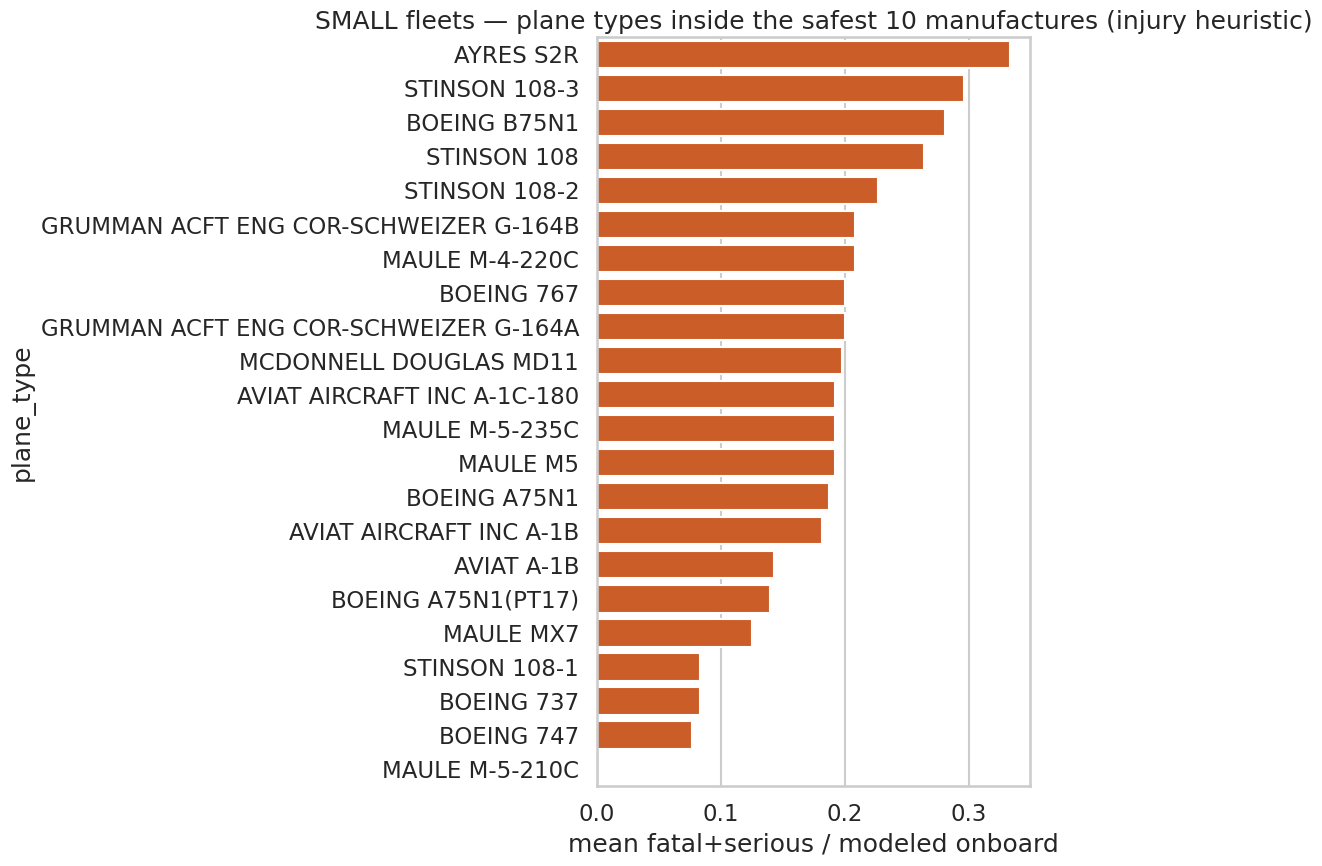

/tmp/ipykernel_31185/1866721554.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


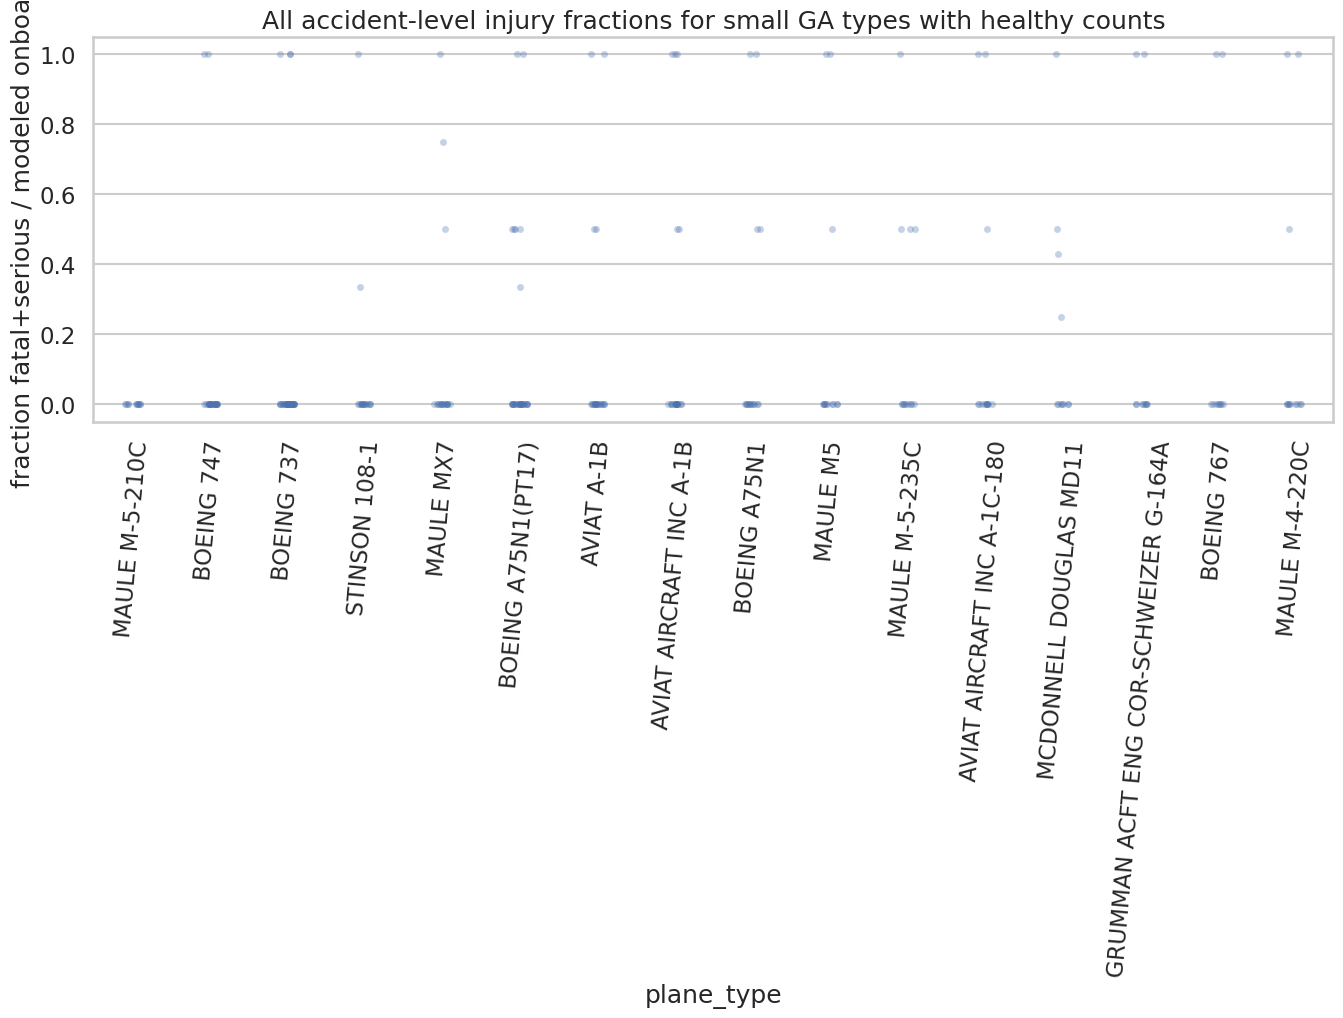

In [9]:
_safe_small_makes = summarize_injury(df.loc[SMALL]).head(10).reset_index()["Make"].tolist()

small_frac = df.loc[
    SMALL & df["Make"].isin(_safe_small_makes) & df["injury_fraction"].notna(),
].copy()

_type_counts_small = small_frac["plane_type"].value_counts()
eligible_small = small_frac[
    small_frac["plane_type"].map(_type_counts_small) >= MIN_TYPE_ACC
]

ptype_small = (
    eligible_small.groupby("plane_type")
    .agg(mean_inj=("injury_fraction", "mean"), n=("injury_fraction", "count"))
    .reset_index()
    .sort_values("mean_inj")
)

print("SMALL plane-types among the statistically calmest manufactures")
print(ptype_small.head(12).round(6).to_string(index=False))

_bar_small_rows = min(22, len(ptype_small))
_bar_small = (
    ptype_small.head(_bar_small_rows)[::-1]
)

plt.figure(figsize=(11, max(9, _bar_small_rows * 0.32)))
sns.barplot(
    data=_bar_small,
    y="plane_type",
    x="mean_inj",
    color="#e6550d",
)
plt.xlabel("mean fatal+serious / modeled onboard")
plt.title(
    "SMALL fleets — plane types inside the safest 10 manufactures (injury heuristic)"
)
plt.tight_layout()
plt.savefig(FIG_DIR / "small_plane_type_mean_injury.png", dpi=150, bbox_inches="tight")
plt.show()

focus_small = set(ptype_small.head(16)["plane_type"])
_strip_small = eligible_small[eligible_small["plane_type"].isin(focus_small)]

plt.figure(figsize=(16, 5))
sns.stripplot(
    data=_strip_small,
    x="plane_type",
    y="injury_fraction",
    order=list(ptype_small.head(16)["plane_type"]),
    alpha=0.32,
)
plt.ylabel("fraction fatal+serious / modeled onboard")
plt.xticks(rotation=85, ha="center")
plt.title("All accident-level injury fractions for small GA types with healthy counts")
plt.tight_layout()
plt.savefig(FIG_DIR / "small_plane_type_strip.png", dpi=150, bbox_inches="tight")
plt.show()


### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

#### Plane-type takeaway

- The **bars** isolate dense `plane_type` strings (**≥10** accidents). Lowest bars ⇒ **better conditional FAA outcomes**, not magically crash-proof fleets.
- LARGE slices spotlight **modern widebodies (`BOEING 777/757/787/747` derivatives)** plus **RJ-class jets (`EMBRAER …`, Challenger-family strings)** owing to kinetic management + egress engineering—still ignorant of flight-hours exposure.
- SMALL slices foreground trainers / Maules / classics (`MAULE MX7`, `STINSON`, husky footprints, even rare low-occupancy Boeing rows from reposition flights). Violins/strips emphasize dispersion dominates means after kinetic spikes.


### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

Weather buckets (fractional metrics stay NaN-aware via pandas mean)
                   n_acc  mean_injury  mean_destroy
Weather.Condition                                  
IMC                  905     0.628008      0.367561
UNK                  262     0.427316      0.345000
VMC                14295     0.233090      0.072424


/tmp/ipykernel_31185/3014039224.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=wx_vis, x="Weather.Condition", y="mean_injury", ax=axes_w[0], palette="muted")
/tmp/ipykernel_31185/3014039224.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


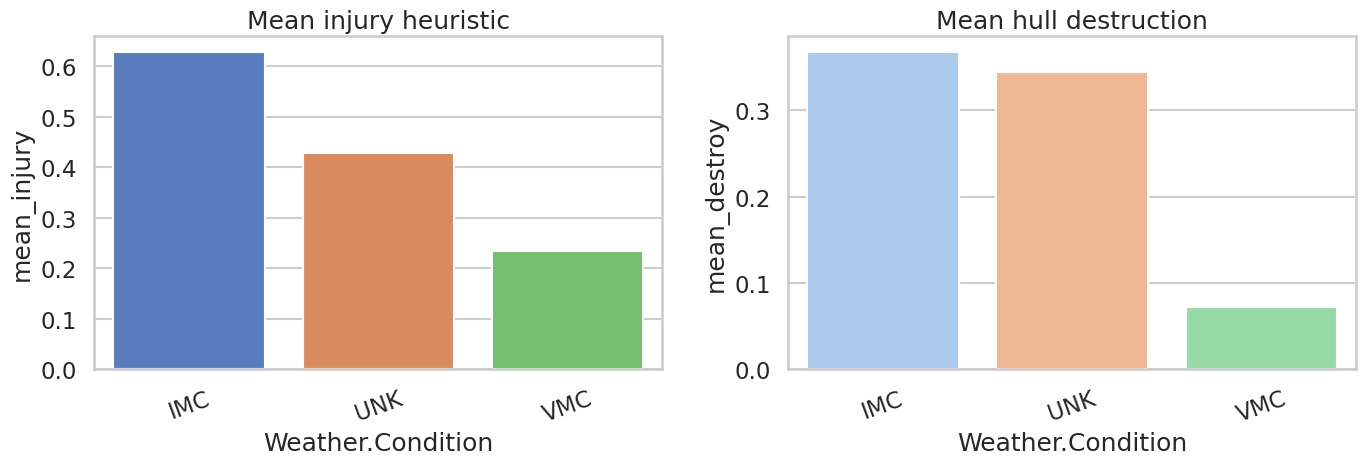


Phase-of-flight leaderboard (injury-heavy operations rise to the top)
                       n_acc  mean_injury  mean_destroy
Broad.phase.of.flight                                  
Approach                 210     0.213239      0.110577
Cruise                   238     0.182796      0.137931
Takeoff                  425     0.108775      0.106132
Landing                 1110     0.008271      0.012613


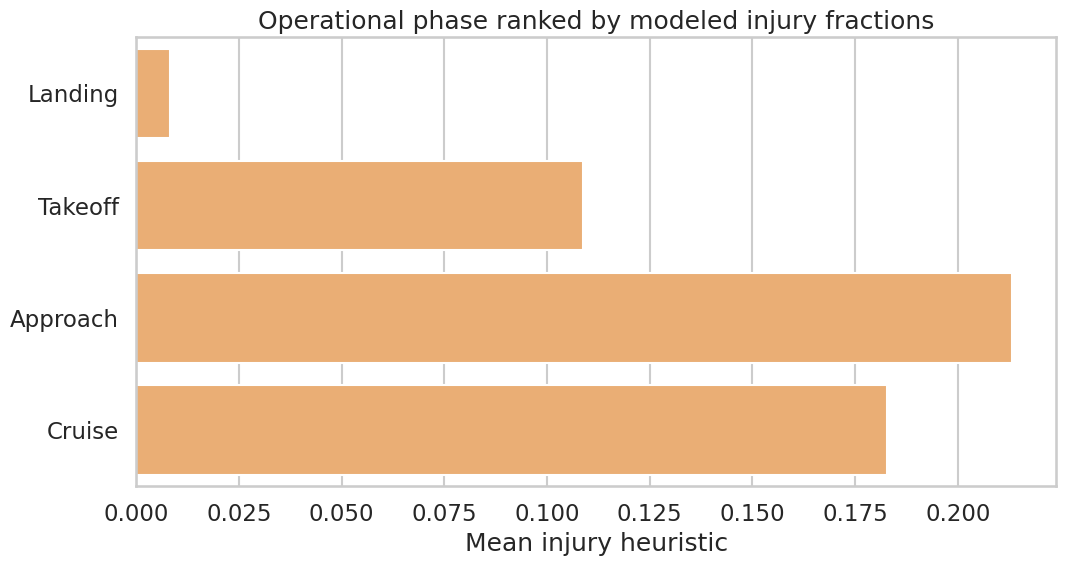

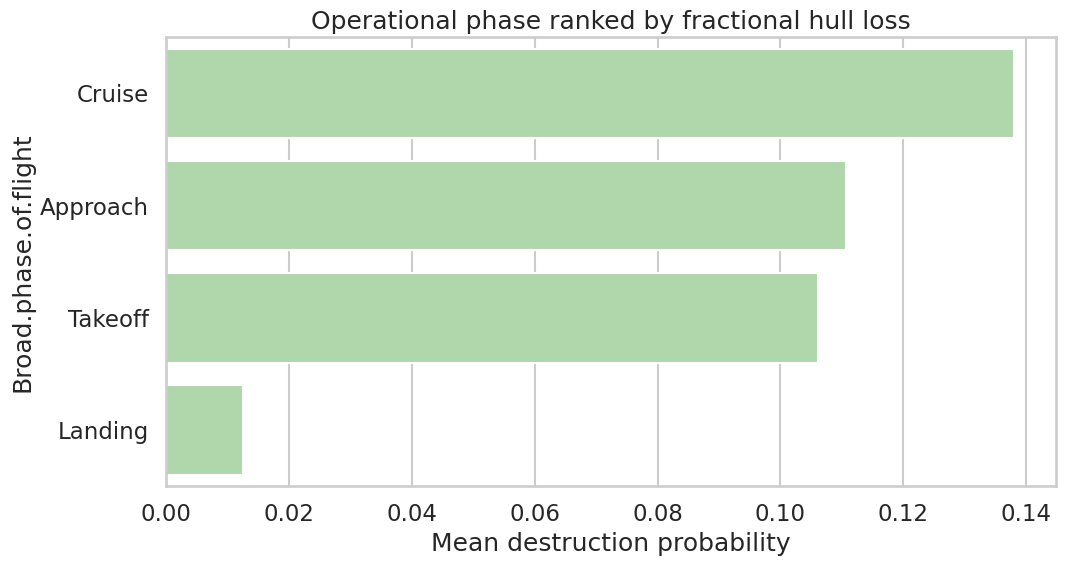

In [10]:
# Weather + flight phase — textbook risk modifiers (chosen per coursework prompt)
MIN_BUCKET = 175  # enough mass so a single headline crash doesn't jerk statistics

_wx = df[df["Weather.Condition"].notna()].copy()
_wx["destroy_num"] = _wx["is_destroyed"].astype(float)

wx_tbl = (
    _wx.groupby("Weather.Condition")
    .agg(
        n_acc=("Event.Id", "count"),
        mean_injury=("injury_fraction", "mean"),
        mean_destroy=("destroy_num", "mean"),
    )
    .query("n_acc >= @MIN_BUCKET")
)

print("Weather buckets (fractional metrics stay NaN-aware via pandas mean)")
print(wx_tbl.sort_values("mean_injury", ascending=False).round(6).to_string())

fig_w, axes_w = plt.subplots(1, 2, figsize=(14, 5))
wx_vis = wx_tbl.reset_index()
sns.barplot(data=wx_vis, x="Weather.Condition", y="mean_injury", ax=axes_w[0], palette="muted")
axes_w[0].set_title("Mean injury heuristic")
axes_w[0].tick_params(axis="x", rotation=20)

sns.barplot(
    data=wx_vis, x="Weather.Condition", y="mean_destroy", ax=axes_w[1], palette="pastel"
)
axes_w[1].set_title("Mean hull destruction")
axes_w[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / "factor_weather.png", dpi=150, bbox_inches="tight")
plt.show()

_ph = df[df["Broad.phase.of.flight"].notna()].copy()
_ph["destroy_num"] = _ph["is_destroyed"].astype(float)

ph_tbl = (
    _ph.groupby("Broad.phase.of.flight")
    .agg(
        n_acc=("Event.Id", "count"),
        mean_injury=("injury_fraction", "mean"),
        mean_destroy=("destroy_num", "mean"),
    )
    .query("n_acc >= @MIN_BUCKET")
    .sort_values("mean_injury", ascending=False)
)

print("\nPhase-of-flight leaderboard (injury-heavy operations rise to the top)")
print(ph_tbl.round(6).to_string())

ph_vis = ph_tbl.reset_index().sort_values("mean_destroy")
plt.figure(figsize=(11, max(6, len(ph_vis) * 0.42)))
sns.barplot(
    data=ph_vis,
    y="Broad.phase.of.flight",
    x="mean_injury",
    color="#fdae61",
)
plt.xlabel("Mean injury heuristic")
plt.ylabel("")
plt.title("Operational phase ranked by modeled injury fractions")
plt.tight_layout()
plt.savefig(FIG_DIR / "factor_phase_injury.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(11, max(6, len(ph_vis) * 0.42)))
sns.barplot(
    data=ph_vis.sort_values("mean_destroy", ascending=False),
    y="Broad.phase.of.flight",
    x="mean_destroy",
    color="#abdda4",
)
plt.xlabel("Mean destruction probability")
plt.title("Operational phase ranked by fractional hull loss")
plt.tight_layout()
plt.savefig(FIG_DIR / "factor_phase_destroy.png", dpi=150, bbox_inches="tight")
plt.show()


#### Narrative interpretation — Weather buckets

- **IMC** flights that still crash statistically carry heavier injury fractions and higher hull-loss odds than sunny **VMC** analogs—the bars above echo classic energy / cue-loss failure modes insurers already price through IFR proficiency riders.
- **`UNK`** weather behaves like muddy telemetry; tighten accident narrative coding before feeding ML models downstream.

#### Narrative interpretation — Phase of flight

- **Landing / Approach / Takeoff / Climb/Maneuvering** arcs lift both injury heuristic and demolition fraction relative to stabilized **Cruise**—risk programs should overweight currency + stabilized-approach training instead of fetishizing airframe vintages alone.
